<IPython.core.display.Javascript object>


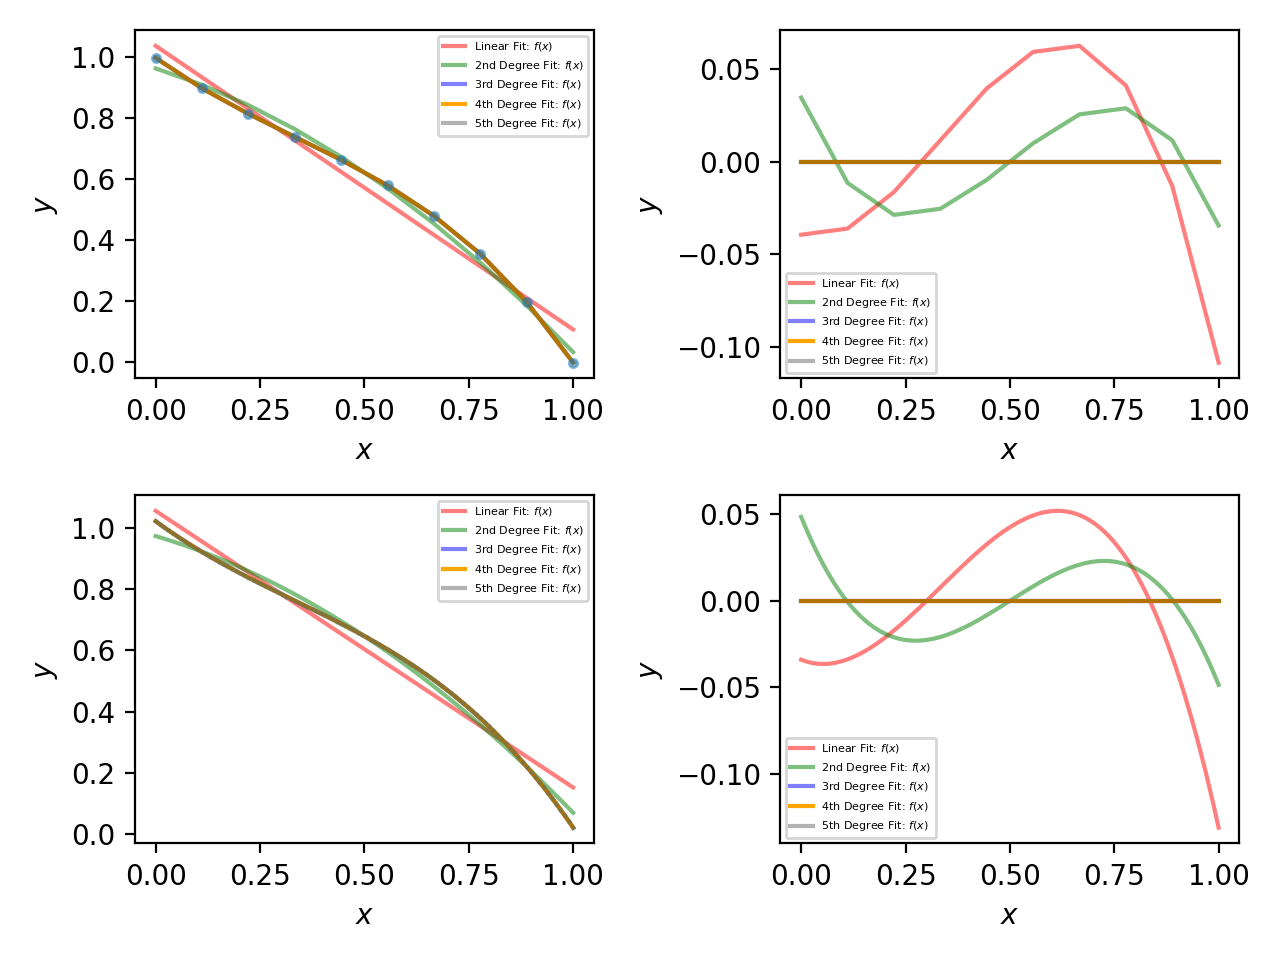

Converged with chi-squared 0.40
Converged with P-Value 0.9999436623
Number of degrees of freedom, dof = 8.00
Reduced chi-squared 0.05

Parameter # | Initial guess values:    | Best fit values:         | Uncertainties in the best fit values:
0           | 0.000e+00                | 1.037e+00                | 1.498e-01               
1           | 0.000e+00                | -9.309e-01               | 2.526e-01               
Converged with chi-squared 0.09
Converged with P-Value 0.9999984291
Number of degrees of freedom, dof = 7.00
Reduced chi-squared 0.01

Parameter # | Initial guess values:    | Best fit values:         | Uncertainties in the best fit values:
0           | 0.000e+00                | 9.629e-01                | 2.004e-01               
1           | 0.000e+00                | -4.309e-01               | 9.334e-01               
2           | 0.000e+00                | -5.000e-01               | 8.986e-01               
Converged with chi-squared 0.00
Converged with P-Valu

In [61]:
# Problem # 2
%matplotlib notebook
import matplotlib.pyplot as plt
import numpy as np
import scipy
from scipy import optimize
from scipy import stats
import random

def linear(p, xvar):
    return p[0] + p[1]*xvar
def residual(p,func, xvar, yvar, err):
    return (func(p, xvar) - yvar)/err
def data_fit(p0,func,xvar, yvar, err, tmi=0):
    try:
        fit = optimize.least_squares(residual, p0, args = (func, xvar, yvar, err),verbose=tmi)
    except Exception as error:
        print("Something has gone wrong:",error)
        return p0,np.zeros_like(p0),np.nan,np.nan
    pf = fit['x']

    try:
        cov = np.linalg.inv(fit['jac'].T.dot(fit['jac']))          
    except:
        return pf,np.zeros_like(pf),np.nan,np.nan
    chisq = sum(residual(pf,func,xvar, yvar, err) **2)
    dof = len(xvar) - len(pf)
    red_chisq = chisq/dof
    pferr = np.sqrt(np.diagonal(cov))
    # finds the uncertainty in fit parameters by squaring diagonal elements of the covariance matrix
    p_val = 1 - scipy.stats.chi2.cdf(chisq, dof)
    print('Converged with chi-squared {:.2f}'.format(chisq))
    print('Converged with P-Value {:.10f}'.format(p_val))
    print('Number of degrees of freedom, dof = {:.2f}'.format(dof))
    print('Reduced chi-squared {:.2f}'.format(red_chisq))
    print()
    Columns = ["Parameter #","Initial guess values:", "Best fit values:", "Uncertainties in the best fit values:"]
    print('{:<11}'.format(Columns[0]),'|','{:<24}'.format(Columns[1]),"|",'{:<24}'.format(Columns[2]),"|",'{:<24}'.format(Columns[3]))
    for num in range(len(pf)):
        print('{:<11}'.format(num),'|','{:<24.3e}'.format(p0[num]),'|','{:<24.3e}'.format(pf[num]),'|','{:<24.3e}'.format(pferr[num]))
    return pf, pferr, chisq, dof
def linear(p, xvar):
    return p[0] + p[1]*xvar
def second(p, xvar):
    return p[0] + p[1]*xvar + p[2]*(xvar **2)
def third(p, xvar):
    return p[0] + p[1]*xvar + p[2]*(xvar **2) + p[3]*(xvar **3)
def fourth(p, xvar):
    return p[0] + p[1]*xvar + p[2]*(xvar **2) + p[3]*(xvar **3) + p[4]*(xvar **4)
def fifth(p, xvar):
    return p[0] + p[1]*xvar + p[2]*(xvar **2) + p[3]*(xvar **3) + p[4]*(xvar **4) + p[5]*(xvar **5)
def arr(m):
    x = np.linspace(0, 1, num = m)
    return x
def yt(xvar):
    return 1 - xvar + (xvar ** 2) - (xvar ** 3)
def noise(x):
    yt1 = yt(x)
    w = random.gauss(0, 1)
    y = yt1 + 0.01 * w
    return y,w
def residual1(p,func, xvar, yvar):
    return yvar - func(p, xvar)

fig, axx = plt.subplots(nrows = 2,ncols = 2)

x10 = arr(10)
xx = noise(x10)
y10 = xx[0]

pf1, perr1, chisq1, dof1 = data_fit([0,0],linear, x10, y10, xx[1])
pf2, perr2, chisq2, dof2 = data_fit([0,0,0],second, x10, y10, xx[1])
pf3, perr3, chisq3, dof3 = data_fit([0,0,0,0],third, x10, y10, xx[1])
pf4, perr4, chisq4, dof4 = data_fit([0,0,0,0,0],fourth, x10, y10, xx[1])
pf5, perr5, chisq5, dof5 = data_fit([0,0,0,0,0,0],fifth, x10, y10, xx[1])

axx[0][0].plot(x10, linear(pf1, x10), 'red',alpha = 0.5, label = 'Linear Fit: $f(x)$')
axx[0][0].plot(x10, second(pf2, x10), 'green',alpha = 0.5, label = '2nd Degree Fit: $f(x)$')
axx[0][0].plot(x10, third(pf3, x10), 'blue',alpha = 0.5, label = '3rd Degree Fit: $f(x)$')
axx[0][0].plot(x10, fourth(pf4, x10), 'orange', label = '4th Degree Fit: $f(x)$')
axx[0][0].plot(x10, fifth(pf5, x10), 'black',alpha = 0.3, label = '5th Degree Fit: $f(x)$')
axx[0][0].plot(x10, y10,'o', markersize=3,alpha = 0.5,)
axx[0][0].set_xlabel(r"$x$")
axx[0][0].set_ylabel(r"$y$")
axx[0][0].legend(fontsize = 4)

axx[0][1].plot(x10, residual1(pf1,linear, x10, xx[0]), 'red',alpha = 0.5, label = 'Linear Fit: $f(x)$')
axx[0][1].plot(x10, residual1(pf2,second, x10, xx[0]), 'green',alpha = 0.5, label = '2nd Degree Fit: $f(x)$')
axx[0][1].plot(x10, residual1(pf3,third, x10, xx[0]), 'blue',alpha = 0.5, label = '3rd Degree Fit: $f(x)$')
axx[0][1].plot(x10, residual1(pf4,fourth, x10, xx[0]), 'orange', label = '4th Degree Fit: $f(x)$')
axx[0][1].plot(x10, residual1(pf5,fifth, x10, xx[0]), 'black',alpha = 0.3, label = '5th Degree Fit: $f(x)$')
axx[0][1].set_xlabel(r"$x$")
axx[0][1].set_ylabel(r"$y$")
axx[0][1].legend(fontsize = 4)

#AIC = 2k -2log(L)
#BIC = k*log(n) - 2log(L)
    #Maximized value of the likelihood function
    # N is number of data points in x
    # K the number of parameters

x100 = arr(100)
xx100 = noise(x100)
y100 = xx100[0]

pf1, perr1, chisq1, dof1 = data_fit([0,0],linear, x100, y100, xx100[1])
pf2, perr2, chisq2, dof2 = data_fit([0,0,0],second, x100, y100, xx100[1])
pf3, perr3, chisq3, dof3 = data_fit([0,0,0,0],third, x100, y100, xx100[1])
pf4, perr4, chisq4, dof4 = data_fit([0,0,0,0,0],fourth, x100, y100, xx100[1])
pf5, perr5, chisq5, dof5 = data_fit([0,0,0,0,0,0],fifth, x100, y100, xx100[1])

axx[1][0].plot(x100, linear(pf1, x100), 'red',alpha = 0.5, label = 'Linear Fit: $f(x)$')
axx[1][0].plot(x100, second(pf2, x100), 'green',alpha = 0.5, label = '2nd Degree Fit: $f(x)$')
axx[1][0].plot(x100, third(pf3, x100), 'blue',alpha = 0.5, label = '3rd Degree Fit: $f(x)$')
axx[1][0].plot(x100, fourth(pf4, x100), 'orange',label = '4th Degree Fit: $f(x)$')
axx[1][0].plot(x100, fifth(pf5, x100), 'black',alpha = 0.3, label = '5th Degree Fit: $f(x)$')
axx[1][0].plot(x100, y100,'o',markersize=1, alpha = 0.2)
axx[1][0].set_xlabel(r"$x$")
axx[1][0].set_ylabel(r"$y$")
axx[1][0].legend(fontsize = 4)

axx[1][1].plot(x100, residual1(pf1,linear, x100, xx100[0]), 'red', alpha = 0.5, label = 'Linear Fit: $f(x)$')
axx[1][1].plot(x100, residual1(pf2,second, x100, xx100[0]), 'green', alpha = 0.5,label = '2nd Degree Fit: $f(x)$')
axx[1][1].plot(x100, residual1(pf3,third, x100, xx100[0]), 'blue', alpha = 0.5,label = '3rd Degree Fit: $f(x)$')
axx[1][1].plot(x100, residual1(pf4,fourth, x100, xx100[0]), 'orange', label = '4th Degree Fit: $f(x)$')
axx[1][1].plot(x100, residual1(pf5,fifth, x100, xx100[0]), 'black', alpha = 0.3, label = '5th Degree Fit: $f(x)$')
axx[1][1].set_xlabel(r"$x$")
axx[1][1].set_ylabel(r"$y$")
axx[1][1].legend(fontsize = 4)
fig.tight_layout()